In [1]:
! git branch

* main


In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pickle as pk
import os, sys


from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve, precision_recall_curve
# import bezier

pd.set_option('future.no_silent_downcasting', True)

In [4]:
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("./"), os.pardir)))
from customFunctions.utils import *
from CustomEstimators.DataFrameUtils import *
from CustomEstimators.PartialPCA import PartialPCA
from CustomEstimators.FilterByCorrelation import FilterByCorrelation
from CustomEstimators.GridSearchOOB_BinaryClassifier import GridSearchOOB_BinaryClassifier

In [5]:
y = pd.read_csv("data/training_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["benign", "pathogenic"], [0,1])
X = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col=0)
X = X.loc[y.index.intersection(X.index)]
y = y.loc[X.index].astype(int)
y

Mithril_id
MITHRIL.1744     1
MITHRIL.1753     0
MITHRIL.1770     0
MITHRIL.1772     1
MITHRIL.1773     0
                ..
MITHRIL.48225    0
MITHRIL.48227    0
MITHRIL.48229    0
MITHRIL.48243    0
MITHRIL.48241    1
Name: label, Length: 684, dtype: int64

In [6]:
embedding = pd.read_csv("data/Mithril_msm_embedding.csv", index_col=0)
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1728,-0.046571,-0.464829,-1.071173,0.706031,0.254538,-0.839300,-0.785148,-0.686940,-0.066750,-0.083101,...,0.703984,-0.094465,0.001146,-0.474778,0.054920,0.746596,-0.846664,0.056164,0.580686,-0.568011
MITHRIL.1729,-0.094558,-0.843313,-0.774938,0.836958,-0.283595,-0.961378,-0.578084,-0.701949,0.039039,-0.158005,...,0.391420,-0.352180,0.091886,-0.714017,0.015839,0.481953,-0.791229,0.398780,0.376998,0.029397
MITHRIL.1730,0.050315,-0.794720,-0.958813,0.551639,-0.071321,-0.767290,-0.558026,-0.843187,0.249865,-0.380568,...,0.306507,-0.153325,0.306693,-0.223419,-0.042577,0.929070,-0.781954,0.641456,0.126171,0.083980
MITHRIL.1731,-0.271729,-0.401465,-0.722368,0.715860,-0.171587,-0.678559,-0.540892,-0.339579,-0.256668,-0.268223,...,0.985569,0.165077,-0.349262,-0.658368,-0.430892,-0.193119,-0.840392,-0.930292,0.894584,-0.970570
MITHRIL.1732,-0.189935,-0.290123,-0.115013,0.859563,-0.127386,-0.715655,-0.411798,-0.926073,-0.151554,-0.170612,...,1.006938,-0.278918,-0.724813,-0.523815,-0.416955,0.000319,-1.031683,-0.880209,1.119973,-0.960705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48239,0.085203,0.720789,0.258117,-0.241561,0.276256,0.001175,0.117050,-0.357717,0.238088,0.165467,...,-0.069218,0.467677,-0.082058,0.037380,0.941805,-0.044995,-0.369644,0.526498,-0.601754,-0.447180
MITHRIL.48240,-0.516000,0.442102,0.331330,0.229251,-0.081880,-0.531516,0.226194,-0.564276,0.209845,-0.133919,...,-0.124533,0.285401,-0.201929,-0.403190,0.809152,0.175132,-0.162785,0.336191,-0.763395,-0.056434
MITHRIL.48241,0.318094,0.357954,-0.837745,-0.545639,-0.157910,0.394076,-1.226594,-0.005673,0.406269,-0.306028,...,-0.098943,0.436399,0.025024,1.110456,-0.265077,0.567142,-0.822745,-0.657988,-0.763098,-0.291456


In [7]:
X_extended = X.join(embedding)
X_extended

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1744,0.917,0.251,0.173366,0.028169,4.4,0.413205,0.412463,0.996305,1.630586,5.0,...,0.770750,-0.166060,-0.769682,-0.203279,-0.407335,0.294421,-0.842909,-1.135103,0.830298,-1.111927
MITHRIL.1753,1.000,8.207,0.201913,0.000000,0.1,0.985947,0.002959,0.999261,0.127290,5.0,...,-0.465848,0.545929,-0.127490,-0.207998,0.693060,-0.263544,-0.920199,0.369574,-0.925618,0.394281
MITHRIL.1770,0.070,0.341,0.257952,0.000000,0.0,0.067258,0.753141,1.000000,1.102995,3.0,...,1.030620,0.257621,-0.270678,0.540452,-0.412045,0.085196,-0.593117,-0.229040,0.058092,0.374886
MITHRIL.1772,0.070,0.341,0.257952,0.000000,0.0,0.067258,0.160384,1.000000,1.102995,3.0,...,0.371670,0.353202,-0.519740,0.372404,-0.530857,0.635173,-0.599045,-0.149641,-0.339720,0.251590
MITHRIL.1773,0.000,-6.741,0.265013,0.000000,0.0,0.207687,0.371027,1.000000,1.797436,3.0,...,0.676963,0.411839,-0.028671,0.240427,-0.337945,-0.028878,-0.562228,-0.444143,-0.040646,0.148496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.48225,0.000,-1.054,0.756382,0.029412,1.0,0.593634,0.005181,0.994845,1.148863,3.0,...,-0.220811,0.182378,0.135448,-0.639994,0.738039,0.264152,-0.215720,0.405794,-0.673857,-0.188454
MITHRIL.48227,0.000,-0.018,0.754119,0.000000,0.5,0.647450,0.308204,0.996318,1.172312,8.0,...,-0.035674,0.628970,-0.321861,0.020001,0.598303,-0.027455,-0.394206,0.411478,-0.298859,-0.741698
MITHRIL.48229,0.000,-0.806,0.749623,0.029412,6.4,0.579956,0.016949,0.999264,1.188829,5.0,...,0.260428,-0.146576,0.153234,-1.010459,0.293505,1.279342,-0.844673,1.046400,-0.021073,-0.325249


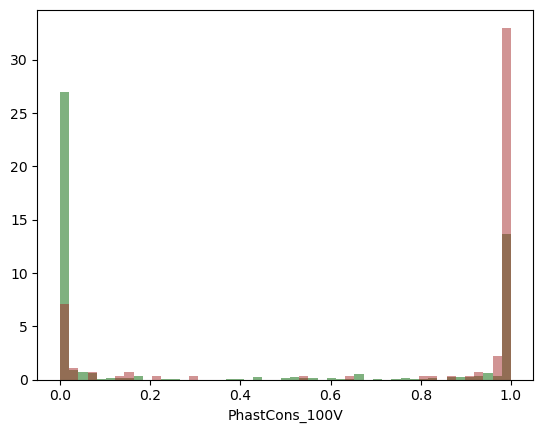

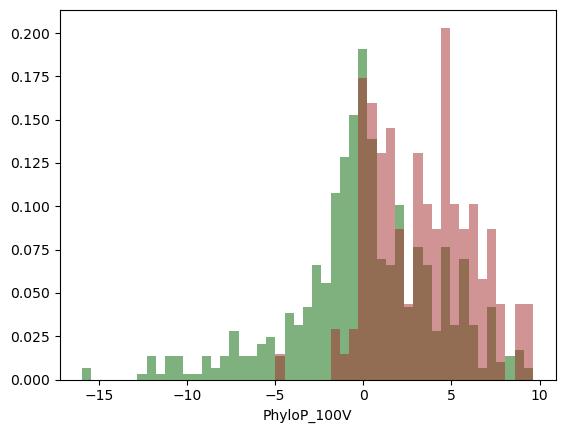

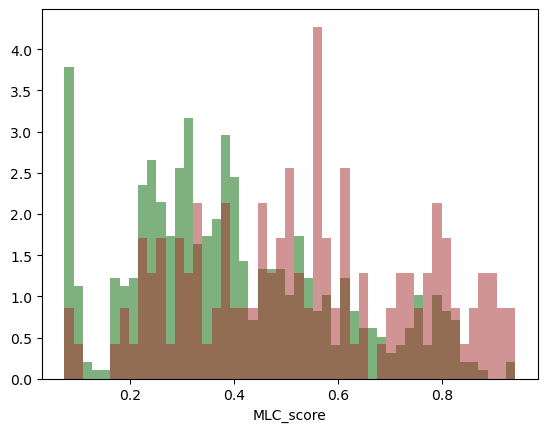

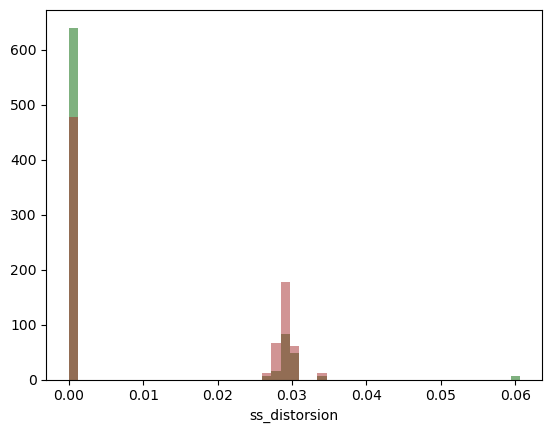

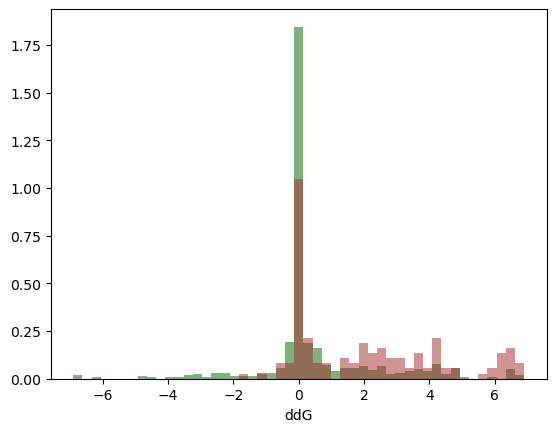

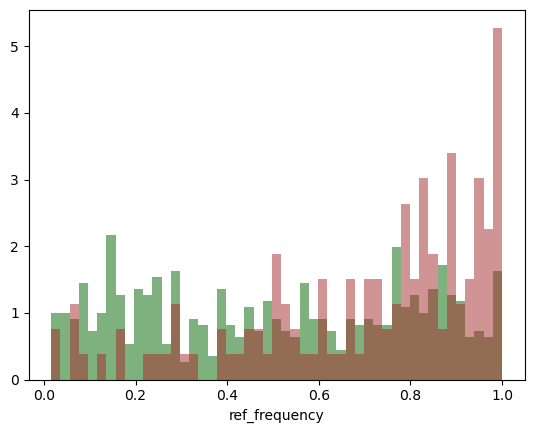

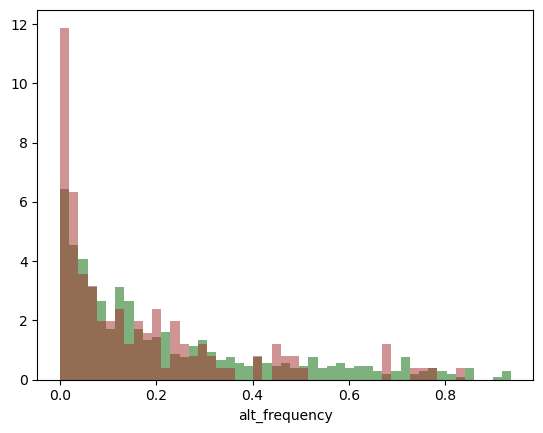

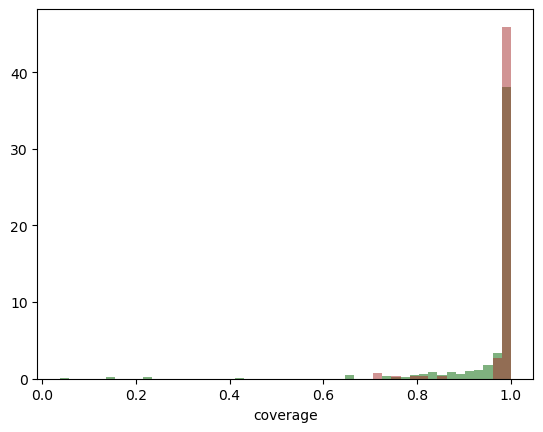

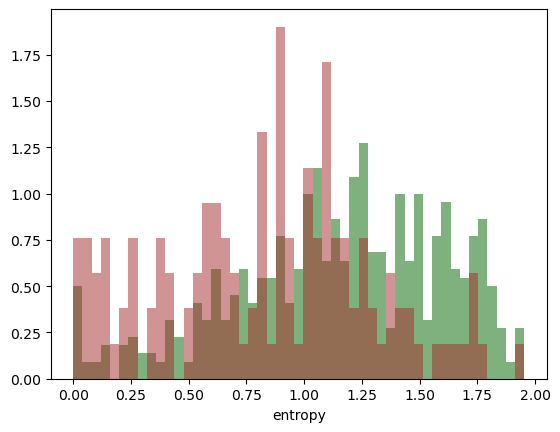

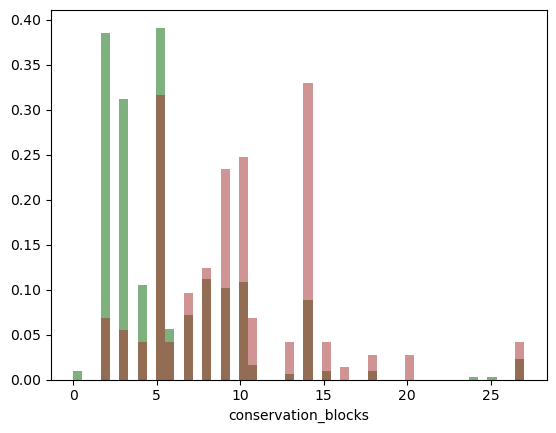

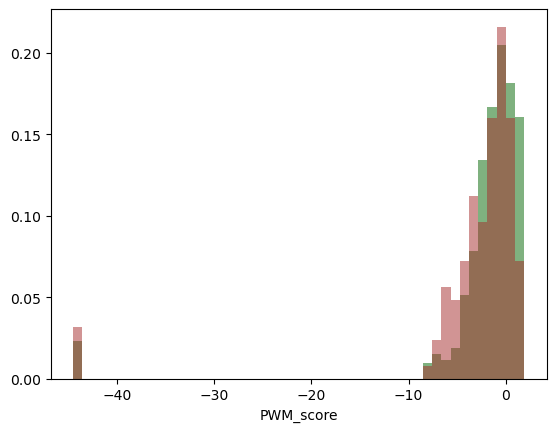

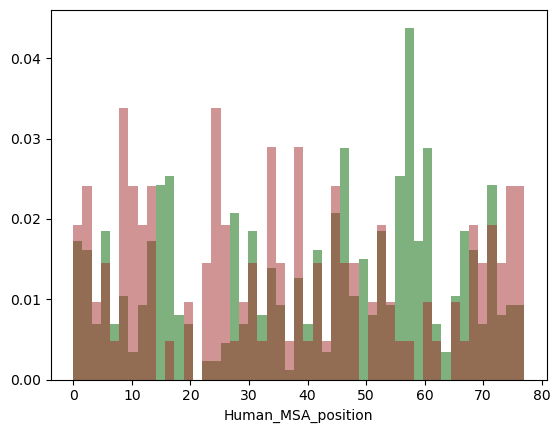

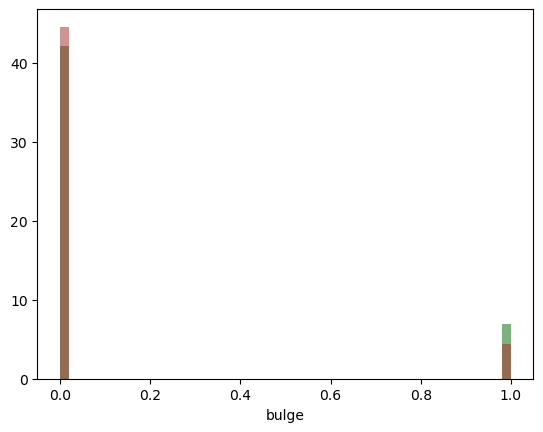

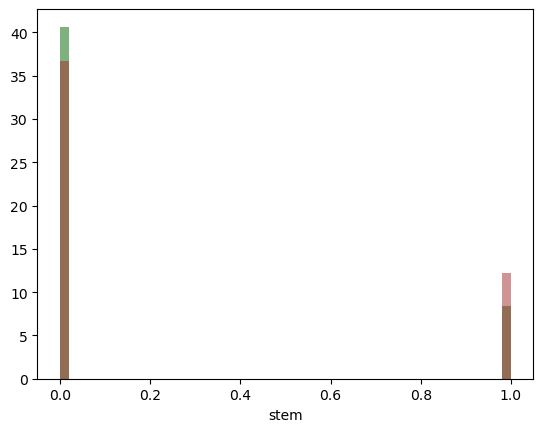

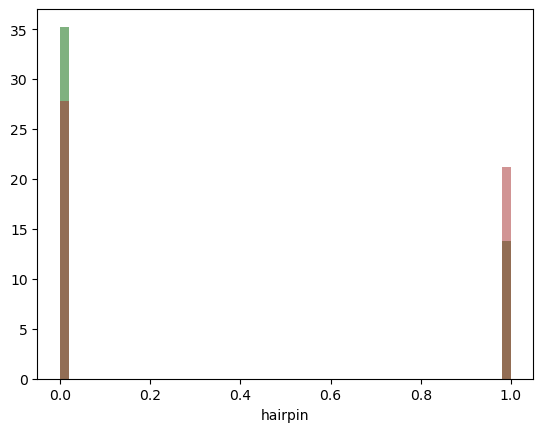

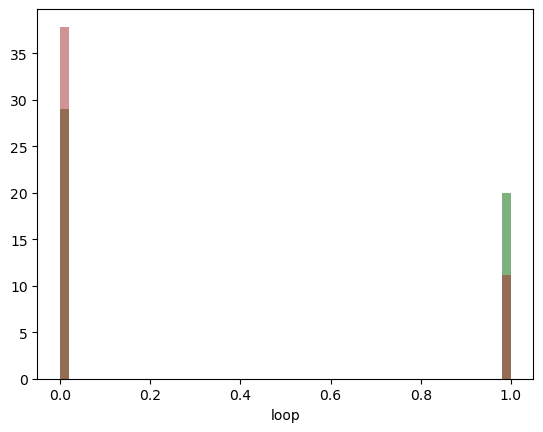

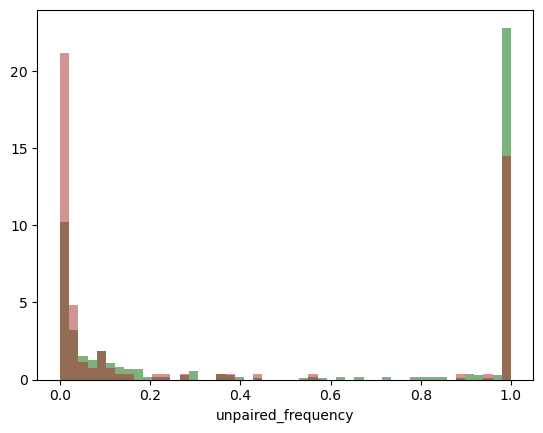

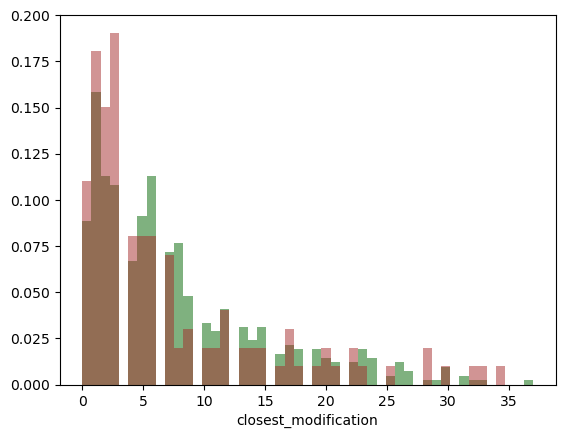

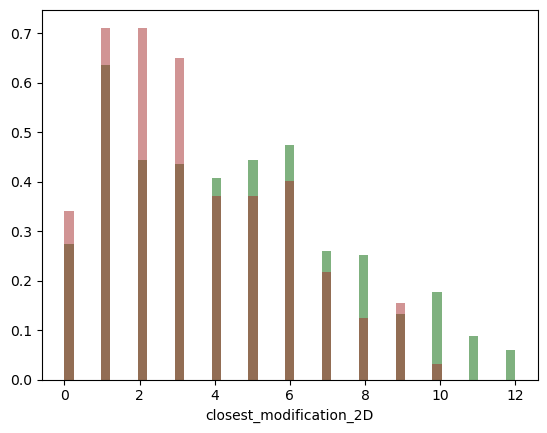

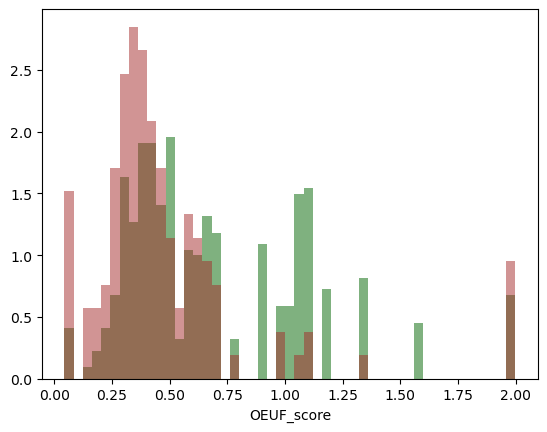

In [8]:
for feature in X.columns:
    try:
        plt.hist(X.loc[y==0, feature], density=True, alpha=.5, color="darkgreen", bins=(np.linspace(X[feature].min(), X[feature].max(), 50)))
        plt.hist(X.loc[y==1, feature], density=True, alpha=.5, color="brown", bins=(np.linspace(X[feature].min(), X[feature].max(), 50)))
    except:
        pass
    plt.xlabel(feature)
    plt.show()

In [9]:
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.svm import SVC
# from imblearn.ensemble import BalancedBaggingClassifier
# from imblearn.under_sampling import RandomUnderSampler

In [10]:
tuned_model_rf = pk.load(open("checkpoints/candidate_models/model_rf.pk", "rb"))
tuned_model_rf

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7d53414a2d40>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [0.025, 0.05, 0.1, 0.2],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7d53401e0360>, verbose=2)

<Axes: >

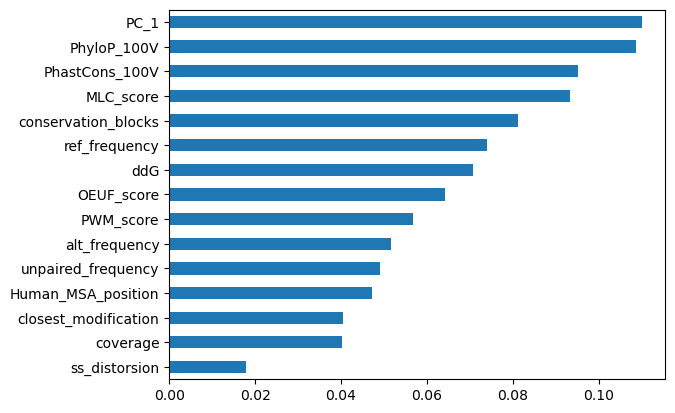

In [11]:
pd.Series(
    tuned_model_rf.best_estimator_[-1].estimator.feature_importances_,
    index=tuned_model_rf.best_estimator_[-1].estimator.feature_names_in_
).sort_values(ascending=True).plot.barh()

In [12]:
tuned_model_knn = pk.load(open("checkpoints/candidate_models/model_knn.pk", "rb"))
tuned_model_knn

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7d53414a2d40>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [0.025, 0.05, 0.1, 0.2],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7d53401e0360>, verbose=2)

In [13]:
tuned_model_svc = pk.load(open("checkpoints/candidate_models/model_svc.pk", "rb"))
tuned_model_svc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7d53414a2d40>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7d53401e0360>, verbose=2)

In [14]:
tuned_model_rf.best_score_, tuned_model_rf.best_params_

(np.float64(0.8194143356643357),
 {'channels_correlation_filter__corr_threshold': 0.3,
  'channels_pca__n_components': 0.2,
  'input_selection__channel_selection__alpha': 0.01,
  'input_selection__feature_selection__threshold': 0.02})

In [15]:
tuned_model_knn.best_score_, tuned_model_knn.best_params_

(np.float64(0.8176073926073926),
 {'channels_correlation_filter__corr_threshold': 0.25,
  'channels_pca__n_components': 0.05,
  'input_selection__channel_selection__alpha': 0.01,
  'input_selection__feature_selection__threshold': 0.01})

In [16]:
tuned_model_svc.best_score_, tuned_model_svc.best_params_

(np.float64(0.831520979020979),
 {'channels_correlation_filter__corr_threshold': 0.25,
  'channels_pca__n_components': 5,
  'input_selection__channel_selection__alpha': 0.01,
  'input_selection__feature_selection__threshold': 0.01})

In [17]:
######################################################
####### We select SVC baging as the best model #######
######################################################

In [18]:
tuned_model_svc.best_estimator_[-1].estimator.feature_names_in_

array(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion',
       'ddG', 'ref_frequency', 'alt_frequency', 'coverage', 'entropy',
       'conservation_blocks', 'PWM_score', 'Human_MSA_position',
       'unpaired_frequency', 'closest_modification', 'OEUF_score', 'PC_1',
       'PC_2', 'PC_3', 'PC_4', 'PC_5'], dtype=object)

In [19]:
tuned_model_svc

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('input_selection',
                                        ColumnTransformerDF(transformers=[('feature_selection',
                                                                           SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                                              random_state=777),
                                                                                             threshold=0.01),
                                                                           Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'ss_distorsion', '...
                                                                       scoring_function=<function roc_auc_score at 0x7d53414a2d40>))]),
             n_jobs=1,
             param_grid={'channels_correlation_filter__corr_threshold': [0.2,
                                                                         0.25,
                                                                         0.3,
                                                                         0.4],
                         'channels_pca__n_components': [1, 2, 3, 5],
                         'input_selection__channel_selection__alpha': [0.01,
                                                                       0.05,
                                                                       0.1],
                         'input_selection__feature_selection__threshold': [0.01,
                                                                           0.02,
                                                                           0.03,
                                                                           0.04,
                                                                           0.05]},
             scoring=<function binary_auROC at 0x7d53401e0360>, verbose=2)

In [24]:
######################################################
############## TEST ON CLINGEN VARIANTS ##############
################# (Dataset 3 and 4) ##################
######################################################

In [25]:
y_test = pd.read_csv("data/test_set.txt", sep="\t", index_col="Mithril_id").label\
    .replace(["Pathogenic", "Likely pathogenic", "Benign", "Likely benign"], [1,1,0,0])
X_test = pd.read_csv("checkpoints/mithril_features.csv", sep="\t", index_col=0)
X_test = X_test.loc[y_test.index.intersection(X_test.index)]
y_test = y_test.loc[X_test.index].astype(int)
y_test

Mithril_id
MITHRIL.1846     1
MITHRIL.4929     1
MITHRIL.9729     1
MITHRIL.9728     1
MITHRIL.9752     1
                ..
MITHRIL.17470    0
MITHRIL.17540    0
MITHRIL.30284    0
MITHRIL.44252    0
MITHRIL.47953    0
Name: label, Length: 71, dtype: int64

In [26]:
X_test_extended = X_test.join(embedding)
X_test_extended

,PhastCons_100V,PhyloP_100V,MLC_score,ss_distorsion,ddG,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1846,1.000,3.707,0.510351,0.028169,1.1,0.942350,0.022173,1.000000,0.408534,14.0,...,0.670284,-0.187625,-0.493014,-0.333382,0.179401,0.408108,-0.683268,-0.737266,0.498617,-1.002428
MITHRIL.4929,0.996,0.980,0.327147,0.000000,0.0,0.817638,0.115845,0.991111,0.922203,5.0,...,0.379588,0.354751,0.390387,-0.997868,-0.110256,0.919109,-0.859502,0.172431,0.486186,-0.654698
MITHRIL.9729,1.000,5.826,0.850926,0.000000,-0.3,0.992614,0.000000,1.000000,0.066377,10.0,...,-0.425040,0.140006,-0.648723,-0.194253,0.805011,0.380403,-0.498180,0.813303,-1.425700,0.438128
MITHRIL.9728,1.000,5.826,0.850926,0.000000,-1.2,0.992614,0.006647,1.000000,0.066377,10.0,...,-0.178584,0.298345,-0.759088,0.083235,1.046968,0.318218,-0.465996,0.723391,-1.183443,0.407064
MITHRIL.9752,0.456,0.908,0.797513,0.000000,0.0,0.739008,0.035547,0.789513,1.215301,9.0,...,-0.057042,0.741527,-0.704968,-0.290943,0.564526,-0.091588,-0.721032,0.827592,-0.592988,0.011270
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.17470,0.000,-0.238,0.312028,0.000000,2.2,0.262963,0.689630,1.000000,1.128278,0.0,...,0.171333,0.873823,-0.128143,0.210718,-0.723211,1.073902,-0.699213,-0.288812,-0.098388,-0.583400
MITHRIL.17540,0.000,0.876,0.656165,0.000000,0.0,0.859806,0.014914,0.993333,0.753068,2.0,...,0.339020,0.419849,-0.422917,-0.410678,-0.192811,0.509847,-0.800014,-0.705664,1.058065,-0.595274
MITHRIL.30284,0.000,-0.125,0.338614,0.000000,0.0,0.858940,0.024259,0.824444,0.884878,3.0,...,-0.495467,0.495154,0.294965,-0.449407,0.286263,-0.445074,-0.055157,-0.037730,-0.095185,-0.331934


In [27]:
y_test_pred = tuned_model_svc.predict_proba(X_test_extended)[:,1]
y_test_pred

array([0.732345  , 0.50320941, 0.69621731, 0.75262256, 0.63744024,
       0.85793906, 0.83934362, 0.68666986, 0.77400988, 0.72928139,
       0.43149472, 0.49104377, 0.57234013, 0.68608416, 0.84613389,
       0.85932213, 0.67258135, 0.52321361, 0.78577154, 0.65718654,
       0.65356851, 0.32980989, 0.60906257, 0.55958534, 0.82106849,
       0.62526668, 0.18718495, 0.5829429 , 0.76037577, 0.79850086,
       0.496178  , 0.68339485, 0.82327001, 0.85963202, 0.17816114,
       0.64541683, 0.47488039, 0.63257534, 0.38715892, 0.29299348,
       0.14235268, 0.19186285, 0.17663704, 0.29799949, 0.20519218,
       0.30766514, 0.11442608, 0.21699814, 0.21413417, 0.22410011,
       0.29971474, 0.15084541, 0.21249193, 0.34205214, 0.10251551,
       0.31188194, 0.14414843, 0.37413483, 0.24597761, 0.23244546,
       0.1147713 , 0.1079891 , 0.54830819, 0.23050929, 0.3294386 ,
       0.22931932, 0.36613684, 0.28403307, 0.18876302, 0.27703376,
       0.6982887 ])

In [28]:
roc_auc_score(
    y_test, y_test_pred
)

np.float64(0.9338118022328549)

In [29]:
average_precision_score(
    y_test, y_test_pred
)

np.float64(0.9482013541948461)

In [30]:
random_ap = np.array([average_precision_score(np.random.permutation(y_test), y_test_pred) for _ in range(10_000)])
random_ap

array([0.6127218 , 0.51085468, 0.52210808, ..., 0.57847502, 0.54456677,
       0.48627016])

In [31]:
(random_ap > average_precision_score(y_test, y_test_pred)).mean()

np.float64(0.0)

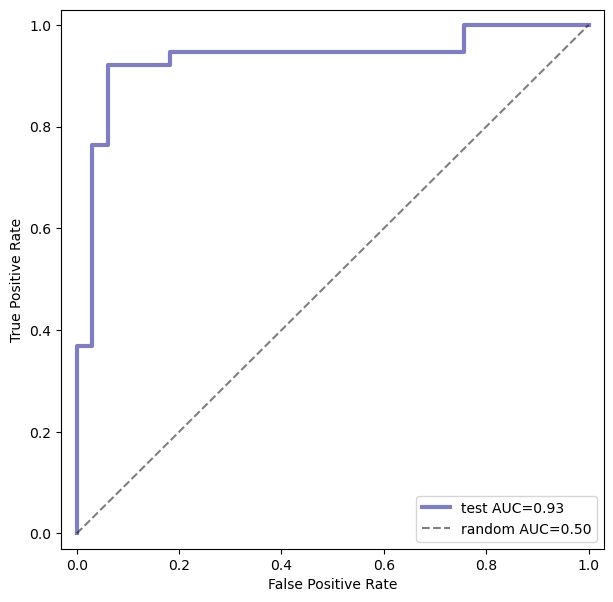

In [34]:
plt.figure(figsize=(7,7))
margin=.03

fpr, tpr, _ = roc_curve(y_test, y_test_pred)
plt.plot(
    [0, *fpr, 1], [0, *tpr, 1],
    color="navy", alpha=.5, linewidth=3, label="test AUC=%.2f"%roc_auc_score(y_test, y_test_pred),
)

plt.plot([0,1], [0,1], linestyle="--", alpha=.5, color="k", label="random AUC=%.2f"%0.5)
plt.xlim(0-margin, 1+margin)
plt.ylim(0-margin, 1+margin)
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

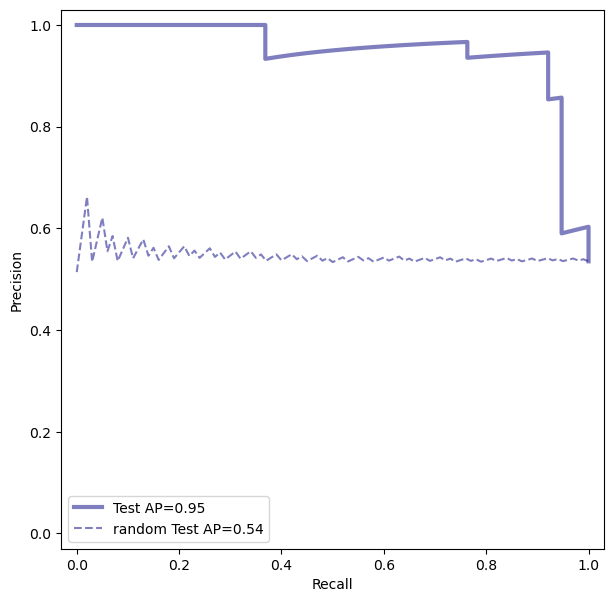

In [35]:
plt.figure(figsize=(7,7))
margin = .03

recall_bins = np.linspace(0, 1, 101)
precision, recall, _ = precision_recall_curve(y_test, y_test_pred)
plt.plot(
    recall, precision,
    color="navy", alpha=.5, linewidth=3, label="Test AP=%.2f" % average_precision_score(y_test, y_test_pred)
)

precisions = []
for _ in range(1000):
    precision, recall, _ = precision_recall_curve(y_test, np.random.rand(len(y_test)))
    precision_interp = np.interp(recall_bins[::-1], recall[::-1], precision[::-1])[::-1]
    precisions.append(precision_interp)
precisions = np.array(precisions)
plt.plot(
    recall_bins, precisions.mean(axis=0), linestyle="--", alpha=.5,
    color="navy", label="random Test AP=%.2f"%y_test.mean()
)

plt.xlim(0 - margin, 1 + margin)
plt.ylim(0 - margin, 1 + margin)
plt.legend()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()